# Analysis of the World Happiness Report (2015–2019)

<br>

## Data Visualization in Python

<br><br>

### Authors

**Arthur Cesbrond Darnaud**  
**Basile Guilloux**


<!-- Table of Contents -->
## Table of Contents
1. [Introduction](#introduction)
2. [Data Loading](#data-loading)
3. [Data Cleaning](#data-cleaning)
4. [Visualizations](#visualizations)
5. [Conclusion](#conclusion)
6. [Sources](#sources)



# Introduction 
<a id="introduction"></a>

This notebook analyses hapiness data from the years 2015 to 2019 with the goal of identifying patterns and trends across sectors years and countries.
The analysis focuses on cleaning and combining multiple yearly datasets into a single notebook, in order to identify correlations and trends over time.

Pandas and NumPy are used for data loading and transformation, while Matplotlib and Seaborn are used to make visualization easier, notably in the study of corelations and casual relationships<sup><a href="#source-1">1</a></sup> , <sup>[2](#source-2)</sup>. Additionally, ggplot style sheet<sup>[3](#source-3)</sup> is used to render aesthetically pleasing plots. Similarly, to make numbers easier to read the display of floating-point numbers is  modified <sup>[4](#source-4)</sup>.

These visual tools help highlight relationships between variables, differences across categories, and overall trends in the data.

By dividing the work from data collection to analysis/visualization, this notebook provides a lens for exploring multi-year contribution data and gaining insights from it.

### Dataset

**Source:** World Happiness Report (via Kaggle / UNSDSN)  
https://www.kaggle.com/datasets/unsdsn/world-happiness/data

The dataset provides yearly measures of happiness scores from more than 150 countries, along with key explanatory variables such as GDP per Capita, Life Expectancy, Social Support, Generosity, Freedom, and Perceptions of Corruption.  
In this project, we focus on the period 2015–2019, which allows for consistent comparisons across countries and years using a common set of indicators.


### Research Question

**What factors are most strongly associated with national happiness and how do these relationships evolve over time between 2015 and 2019?**

More specifically, our analysis examines whether economic, social and institutional dimensions (income levels, social support, health, and governance) are consistently linked to happiness across countries, and whether their importance evolves over time.



<a id="data-loading"></a>
# Data Loading

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

In [2]:
from pathlib import Path

try:
    from google.colab import drive
    drive.mount("/content/drive")
    data_dir = Path("/content/drive/MyDrive/HappinessProject/data")
except ModuleNotFoundError:
    # Not running in Colab (for example, opened straight from the GitHub
    # repo) -> fall back to the data/ folder that sits next to this notebook.
    data_dir = Path("data")


This following code reads the annual CSV files. It adds a Year column to each, and concatenates them into a single combined DataFrame. It creates a dictionary (data_by_year) that stores each dataset as a separate data frame keyed by the year.<sup>[5](#source-5)</sup>, <sup>[6](#source-6)</sup>

In [3]:
# Years included in the analysis
years = [2015, 2016, 2017, 2018, 2019]

data_by_year = {}
dfs = []

for year in years:
    filepath = data_dir / f"{year}.csv"

    if not filepath.exists():
        print(f"File not found for year {year}: {filepath}")
        continue

    df = pd.read_csv(filepath)
    df["Year"] = year

    data_by_year[year] = df
    dfs.append(df)

# Combine all years into a single DataFrame
df_all_years = pd.concat(dfs, ignore_index=True)

print("Years loaded:", sorted(data_by_year.keys()))
print("Combined dataset shape:", df_all_years.shape)

Years loaded: [2015, 2016, 2017, 2018, 2019]
Combined dataset shape: (782, 31)


<a id="data-cleaning"></a>
# Data cleaning.<sup>[7](#source-7)</sup>

To ensure that multiple yearly datasets remain consistent, column names are standardized using a a common label and a mapping dictionary.
Because the same variables are labeled differently across years, a column-mapping approach is used to rename all variants to a single set of column names.
This harmonization step ensures that datasets from different years can be combined reliably and analyzed together. <sup>[8](#source-8)</sup>


In [4]:
for year, df_year in data_by_year.items():
    print(f"\nColumns in raw dataset for year {year}:")
    print(df_year.columns.tolist())
    print(df_year.isna().sum())


Columns in raw dataset for year 2015:
['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual', 'Year']
Country                          0
Region                           0
Happiness Rank                   0
Happiness Score                  0
Standard Error                   0
Economy (GDP per Capita)         0
Family                           0
Health (Life Expectancy)         0
Freedom                          0
Trust (Government Corruption)    0
Generosity                       0
Dystopia Residual                0
Year                             0
dtype: int64

Columns in raw dataset for year 2016:
['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Lower Confidence Interval', 'Upper Confidence Interval', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)

#

In [5]:

# This dictionary maps old column names to the standardized column names we want
# to keep, since dictionnary keys are unique.

target_cols = ["Country","Region","Happiness Score","GDP per Capita","Social Support",
               "Life Expectancy","Freedom","Generosity","Corruption","Year",]


mapping_15_19 = {"Country": "Country","Country or region": "Country",
                 "Region": "Region","Happiness Score": "Happiness Score",
                 "Happiness.Score": "Happiness Score","Score": "Happiness Score",
                 "Economy (GDP per Capita)": "GDP per Capita",
                 "Economy..GDP.per.Capita.": "GDP per Capita",
                 "GDP per capita": "GDP per Capita",
                 "Family": "Social Support","Social support": "Social Support",
                 "Health (Life Expectancy)": "Life Expectancy","Health..Life.Expectancy.": "Life Expectancy",
                 "Healthy life expectancy": "Life Expectancy","Freedom": "Freedom",
                 "Freedom to make life choices": "Freedom","Generosity": "Generosity",
                 "Trust (Government Corruption)": "Corruption","Trust..Government.Corruption.": "Corruption",
                 "Perceptions of corruption": "Corruption",}


This block loops through the datasets from 2015 to 2019. It standardizes their column names, and keeps only the columns listed in the target. It skips any year that wasn’t loaded , collects the cleaned yearly DataFrames in a list, and then combines them into one dataset with pd.concat.<sup>[9](#source-9)</sup> Finally, it prints the resulting dataset size and displays the first few rows so you can check that everything went correctly.

In [6]:

# List that will store the cleaned DataFrames for each year (2015–2019)
dfs_15_19 = []

# Loop over the years 
for year in range(2015, 2020):

    # Create a copy of the yearly DataFrame to avoid changing the original
    df_year = data_by_year[year].copy()

    # Standardize column names using a predefined mapping
    # This ensures consistency across years with different column labels
    df_year = df_year.rename(columns=mapping_15_19)

    # Keep only the target columns that are actually present in this year's dataset
    cols_present = [c for c in target_cols if c in df_year.columns]

    # If none of the required columns are present, skip this year
    if not cols_present:
      print(f"No target column for year {year}")
      continue

    # Append the cleaned subset of columns for this year to the list
    dfs_15_19.append(df_year[cols_present])

# ensure that at least one DataFrame is available for concatenation
if not dfs_15_19:
    raise ValueError("No dataframe to concatenate.")

# Concatenate all cleaned yearly DataFrames into a dataset
df_15_19 = pd.concat(dfs_15_19, ignore_index=True)

# the first rows of the cleaned combined dataset
df_15_19.head()

,Country,Region,Happiness Score,GDP per Capita,Social Support,Life Expectancy,Freedom,Generosity,Corruption,Year
0,Switzerland,Western Europe,7.587,1.397,1.350,0.941,0.666,0.297,0.420,2015
1,Iceland,Western Europe,7.561,1.302,1.402,0.948,0.629,0.436,0.141,2015
2,Denmark,Western Europe,7.527,1.325,1.361,0.875,0.649,0.341,0.484,2015
3,Norway,Western Europe,7.522,1.459,1.331,0.885,0.670,0.347,0.365,2015
4,Canada,North America,7.427,1.326,1.323,0.906,0.633,0.458,0.330,2015


A quick look at the raw country lists shows a few entities are spelled differently depending on the year, for example Taiwan only shows up as "Taiwan Province of China" in the 2017 file, and Hong Kong shows up once as "Hong Kong S.A.R., China". Left alone, these would silently split into separate "countries" once we start grouping by `Country` later in the notebook (and, as it turns out, they also break the Region lookup we build a few steps down, since only the 2015 and 2016 files carry a Region column and everything else has to match on country name to inherit one). The mapping below folds these back into one consistent name per country before anything else touches the data.

In [7]:
# A handful of countries are spelled inconsistently across the yearly
# files (mostly long official names formatted differently year to year).
# We fold them back together here so a later groupby("Country") does not
# quietly treat, say, "Taiwan" and "Taiwan Province of China" as two
# different countries.
country_name_mapping = {
    "Taiwan Province of China": "Taiwan",
    "Hong Kong S.A.R., China": "Hong Kong",
    "Northern Cyprus": "North Cyprus",
    "Trinidad & Tobago": "Trinidad and Tobago",
    "Macedonia": "North Macedonia",  # official name since February 2019
    "Somaliland region": "Somaliland Region",
}

df_15_19["Country"] = df_15_19["Country"].replace(country_name_mapping)


In [8]:
# Assigning the cleaned dataset to a final variable
df_final = df_15_19

# Display asummary of the dataset
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country          782 non-null    str    
 1   Region           315 non-null    str    
 2   Happiness Score  782 non-null    float64
 3   GDP per Capita   782 non-null    float64
 4   Social Support   782 non-null    float64
 5   Life Expectancy  782 non-null    float64
 6   Freedom          782 non-null    float64
 7   Generosity       782 non-null    float64
 8   Corruption       781 non-null    float64
 9   Year             782 non-null    int64  
dtypes: float64(7), int64(1), str(2)
memory usage: 61.2 KB


This section checks how many missing values (NaNs) exist in each column so you can see where data is incomplete.<sup>[10](#source-10)</sup>

In [9]:
df_final.isna().sum()

Country              0
Region             467
Happiness Score      0
GDP per Capita       0
Social Support       0
Life Expectancy      0
Freedom              0
Generosity           0
Corruption           1
Year                 0
dtype: int64

This line extracts all non-missing country, region pairs, removes duplicate countries and converts the result into a dictionary that provides a country → region mapping <sup>[11](#source-11)</sup>.

In [10]:
# Creating a mapping using available (non-missing) values
region_mapping = (
    df_final[["Country", "Region"]]
    .dropna() # Keep only rows where Region is known
    .drop_duplicates(subset=["Country"]) # Ensure one region per country
    .set_index("Country")["Region"] # Use Country as key and Region as value
    .to_dict())

The following fills missing Region values using the country–region mapping and then verifies the result by checking how many regions are still missing and previewing a few region labels. Inspiration drawn from Saito Kentaro on DNM <sup>[12](#source-12)</sup>.

In [11]:
# Fill missing Region values using the country-to-region mapping
df_final["Region"] = df_final.apply(lambda row: region_mapping.get(row["Country"], row["Region"]),axis=1)

In [12]:
# Checking how many region values remain missing after the filling step
df_final["Region"].isna().sum()

# Displays a sample of unique region values for verification. We want the first ten with slicing.
df_final["Region"].unique()[:10]

<StringArray>
[                 'Western Europe',                   'North America',
       'Australia and New Zealand', 'Middle East and Northern Africa',
     'Latin America and Caribbean',               'Southeastern Asia',
      'Central and Eastern Europe',                    'Eastern Asia',
              'Sub-Saharan Africa',                   'Southern Asia']
Length: 10, dtype: str


These steps allowed us to ensure consistent region labels across all years from 2015 to 2019. Now we fill missing numerical values with column means to keep the dataset usable without giving up rows.

In [13]:
# List of variables used in the analysis
numeric_cols = ["Happiness Score","GDP per Capita","Social Support","Life Expectancy","Freedom","Generosity","Corruption"]

for col in numeric_cols:
    if col in df_final.columns:
        # Convert the column to float to avoid type issues
        df_final[col] = df_final[col].astype(float)

        # Replacing missing values with that YEAR's mean rather than the
        # mean across all five years, so the handful of gaps we're patching
        # don't quietly flatten out the time trends we're studying later on
        df_final[col] = df_final.groupby("Year")[col].transform(lambda s: s.fillna(s.mean()))


In [14]:
df_final.isna().sum()

Country            0
Region             1
Happiness Score    0
GDP per Capita     0
Social Support     0
Life Expectancy    0
Freedom            0
Generosity         0
Corruption         0
Year               0
dtype: int64

In [15]:
df_final.head()

,Country,Region,Happiness Score,GDP per Capita,Social Support,Life Expectancy,Freedom,Generosity,Corruption,Year
0,Switzerland,Western Europe,7.587,1.397,1.350,0.941,0.666,0.297,0.420,2015
1,Iceland,Western Europe,7.561,1.302,1.402,0.948,0.629,0.436,0.141,2015
2,Denmark,Western Europe,7.527,1.325,1.361,0.875,0.649,0.341,0.484,2015
3,Norway,Western Europe,7.522,1.459,1.331,0.885,0.670,0.347,0.365,2015
4,Canada,North America,7.427,1.326,1.323,0.906,0.633,0.458,0.330,2015


The World Happiness Report datasets from 2015 to 2019 do not use  consistent column names across years, and a few countries are not even spelled the same way from one year to the next.
To address this, we define a standardized schema and created a mapping table to harmonize variable names, plus a second mapping to fold inconsistently-spelled countries (Taiwan, Hong Kong, North Cyprus, Trinidad and Tobago, Macedonia/North Macedonia) back into a single name each so later groupby steps don't quietly split them apart.
Only the variables required for our analysis were kept.
After adding the yearly datasets into a single table, we handled missing values by replacing them with that year's column mean for numerical variables, rather than one mean across all five years, so the handful of gaps we filled don't flatten out the trends we're studying.
This process produced a clean dataset ideal for  analysis across the 2015–2019 period. Now we store the cleaned dataset which we will use as main source of analysis:


In [16]:
# Define the output path (falls back next to the data/ folder when not in Colab)
output_path = data_dir / "WHR_2015_2019_Cleaned.csv"

# Save the cleaned dataset as a CSV file
df_final.to_csv(output_path, index=False)

print(f"Cleaned dataset saved to: {output_path}")


Cleaned dataset saved to: data/WHR_2015_2019_Cleaned.csv


# Data analysis

In this section, we use the cleaned 2015–2019 dataset to understand what drives the differences in happiness across the countries, years, and the regions.


## 1) What do the main variables look like overall?


**Question:** What are the typical levels and variability of the happiness score and its main explanatory factors across 2015–2019?

The main characteristics of the dataset are summarized using the Pandas describe() function.<sup>[13](#source-13)</sup>

In [17]:
df_final.describe()

,Happiness Score,GDP per Capita,Social Support,Life Expectancy,Freedom,Generosity,Corruption,Year
count,782.000,782.000,782.000,782.000,782.000,782.000,782.000,782.000
mean,5.379,0.916,1.078,0.612,0.411,0.219,0.125,"2,016.994"
std,1.127,0.407,0.330,0.248,0.153,0.122,0.106,1.417
min,2.693,0.000,0.000,0.000,0.000,0.000,0.000,"2,015.000"
25%,4.510,0.607,0.869,0.440,0.310,0.130,0.054,"2,016.000"
50%,5.322,0.982,1.125,0.647,0.431,0.202,0.091,"2,017.000"
75%,6.190,1.236,1.327,0.808,0.531,0.279,0.156,"2,018.000"
max,7.769,2.096,1.644,1.141,0.724,0.838,0.552,"2,019.000"


**Interpretation:** This summary provides a baseline for our analysis because it shows the overall ranges and dispersion of each factor.

## Distribution of Happiness Scores (2015–2019)
**Question:** How are Happiness Scores distributed across countries, and do most countries cluster around similar levels or show large disparities?

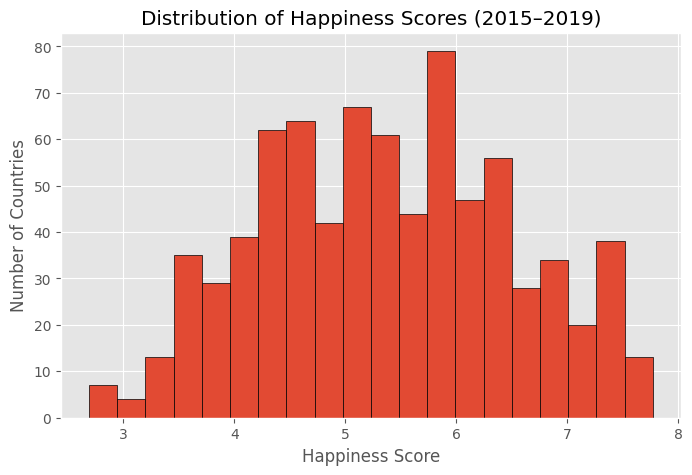

In [18]:
plt.figure(figsize=(8, 5))
plt.hist(df_final["Happiness Score"], bins=20, edgecolor="black")
plt.xlabel("Happiness Score")
plt.ylabel("Number of Countries")
plt.title("Distribution of Happiness Scores (2015–2019)")
plt.show()

**Interpretation:** The histogram indicates that most countries have happiness scores between roughly 4.5 and 6.5 showing that the majority of countries fall within a narrow middle range. Fewer countries appear at the extremes, with very low scores below 3.5 and very high scores above 7 being rare. This asymmetric distribution suggests that extreme happiness outcomes are rare, while moderate levels of happiness are much more widespread across countries.

## 2) Which factors are most associated with happiness?

**Question:** Which factors have the strongest positive or negative correlation with the Happiness Score over 2015–2019?

The following step computes a correlation matrix<sup>[14](#source-14)</sup> for the main numeric happiness factors, allowing us to quickly assess the correlations between the happiness score and its contributing variables.

In [19]:
# Select the variables of interest for correlation analysis
corr_cols = ["Happiness Score","GDP per Capita","Social Support","Life Expectancy","Freedom","Generosity","Corruption"]

corr_matrix = df_final[corr_cols].corr()
corr_matrix


,Happiness Score,GDP per Capita,Social Support,Life Expectancy,Freedom,Generosity,Corruption
Happiness Score,1.000,0.789,0.649,0.742,0.551,0.138,0.398
GDP per Capita,0.789,1.000,0.586,0.784,0.341,-0.015,0.304
Social Support,0.649,0.586,1.000,0.573,0.420,-0.037,0.126
Life Expectancy,0.742,0.784,0.573,1.000,0.341,0.011,0.250
Freedom,0.551,0.341,0.420,0.341,1.000,0.291,0.460
Generosity,0.138,-0.015,-0.037,0.011,0.291,1.000,0.319
Corruption,0.398,0.304,0.126,0.250,0.460,0.319,1.000


# Visualizations 
<a id="visualizations"></a>

Plotting the correlation heatmap with seaborn yields.

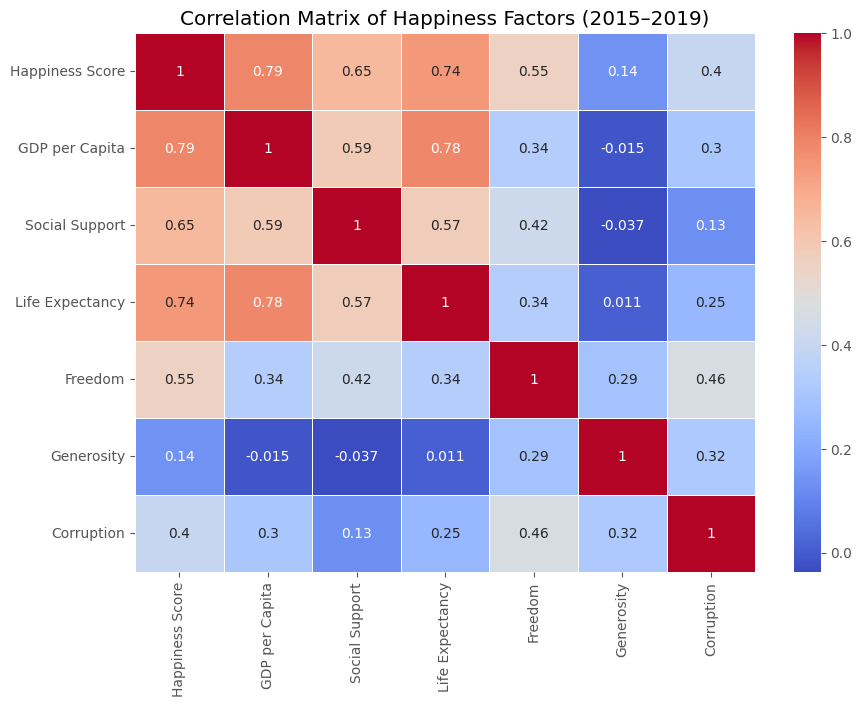

In [20]:
plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=.5)
plt.title("Correlation Matrix of Happiness Factors (2015–2019)")
plt.show()


**Interpretation:** The correlation matrix shows that Happiness Score is most strongly associated with GDP per Capita (≈0.79) and Life Expectancy (≈0.74), followed by Social Support (≈0.65). Freedom displays a moderate positive correlation, while Generosity shows only a weak relationship with happiness. The matrix also reveals strong correlations between GDP per Capita and Life Expectancy (≈0.78), which suggest that economic development and health outcomes tend to move together. Overall, the results highlight that economic and health-related factors are more closely linked to happiness than altruistic behaviors like the generosity.

## Relationship between GDP per Capita and Happiness

**Question:** How does GDP per Capita relate to the Happiness Score across countries, and does higher income always imply higher happiness?

To further explore the relationship identified in the correlation analysis, we visualize the association between GDP per Capita and the Happiness Score at the country level. This scatter plot allows us to assess both the overall trend and the dispersion of happiness levels across countries with similar income levels.


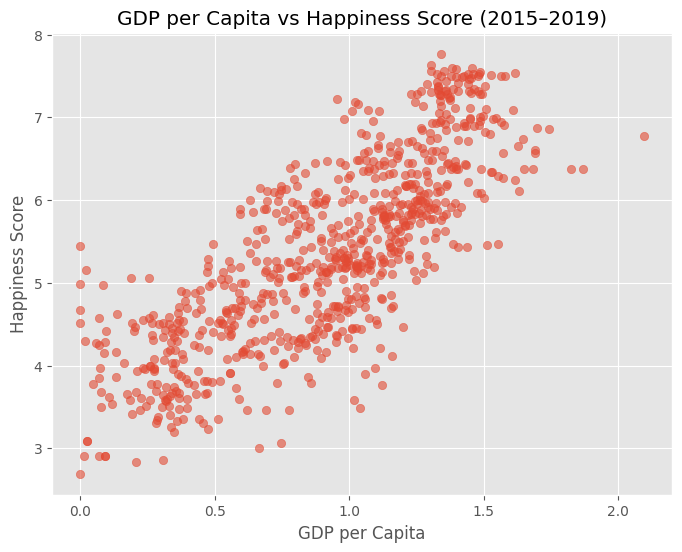

In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(
    df_final["GDP per Capita"],
    df_final["Happiness Score"],
    alpha=0.6)
plt.xlabel("GDP per Capita")
plt.ylabel("Happiness Score")
plt.title("GDP per Capita vs Happiness Score (2015–2019)")
plt.show()

**Interpretation:** The scatter plot reveals a clear upward trend between GDP per Capita and Happiness Score, indicating that wealthier countries tend to report higher happiness levels. However, the wide vertical spread at similar GDP levels shows that countries with comparable income can exhibit some very different happiness outcomes. This dispersion suggests diminishing returns to income at higher GDP levels and highlights the role of some non-economic factors, such as the social support, the health, and institutional quality, in shaping happiness.

## 3) How do global averages evolve over time (2015–2019)?

**Question:** Do the global averages of happiness and its key factors change meaningfully from 2015 to 2019?

We compute yearly averages of the main happiness variables by grouping the dataset by year and taking the mean for each factor. We then plot those yearly mean values as time-series lines<sup>[15](#source-15)</sup>,<sup>[16](#source-16)</sup> , letting you see how the global average of happiness score, GDP per capita, social support, freedom, generosity, and corruption changes from 2015 to 2019.

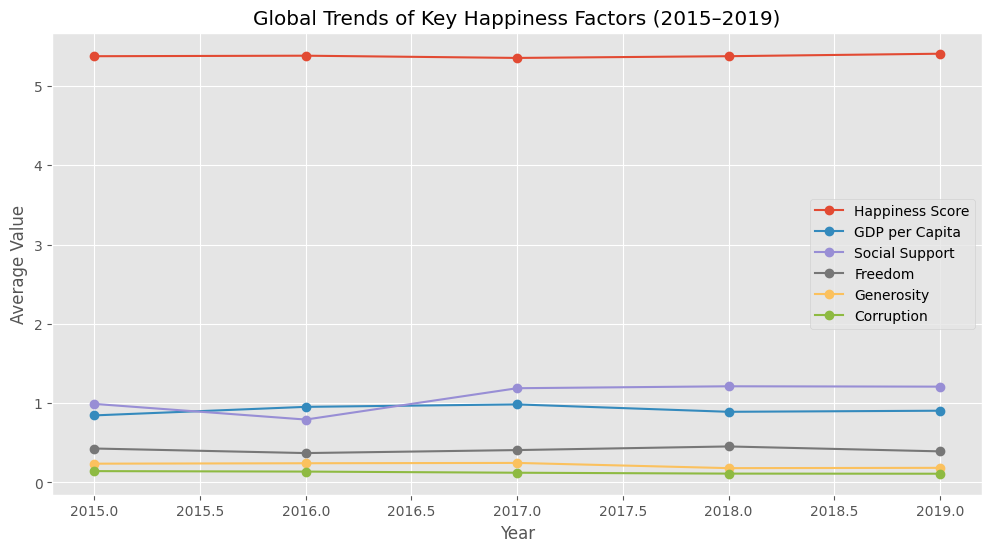

In [22]:

year_means = df_final.groupby("Year")[["Happiness Score", "GDP per Capita", "Social Support", "Freedom", "Generosity", "Corruption"]].mean()

plt.figure(figsize=(12, 6))
plt.plot(year_means.index, year_means["Happiness Score"], marker="o", label="Happiness Score")
plt.plot(year_means.index, year_means["GDP per Capita"], marker="o", label="GDP per Capita")
plt.plot(year_means.index, year_means["Social Support"], marker="o", label="Social Support")
plt.plot(year_means.index, year_means["Freedom"], marker="o", label="Freedom")
plt.plot(year_means.index, year_means["Generosity"], marker="o", label="Generosity")
plt.plot(year_means.index, year_means["Corruption"], marker="o", label="Corruption")

plt.title("Global Trends of Key Happiness Factors (2015–2019)")
plt.xlabel("Year")
plt.ylabel("Average Value")
plt.legend()
plt.grid(True)
plt.show()

**Interpretation**: The line plot shows that the average global Happiness Score remains relatively stable between 2015 and 2019, with only small year-to-year fluctuations. Economic and social indicators such as GDP per Capita and Social Support display modest variations over the period, while variables like Generosity and Corruption remain consistently low and relatively flat. Overall, the plot suggests that changes in global averages are limited, indicating that differences in happiness are driven more by cross-country variation than by strong global time trends during this period.

## 4) Which factors contribute the most on average?

**Question:** Across 2015–2019, which factors have the highest average contribution values in the dataset?

After examining correlations and bivariate relationships, we now compare the average contribution of each factor to the Happiness Score over the period 2015–2019. This visualization highlights which dimensions consistently account for larger portions of the happiness measure across countries.


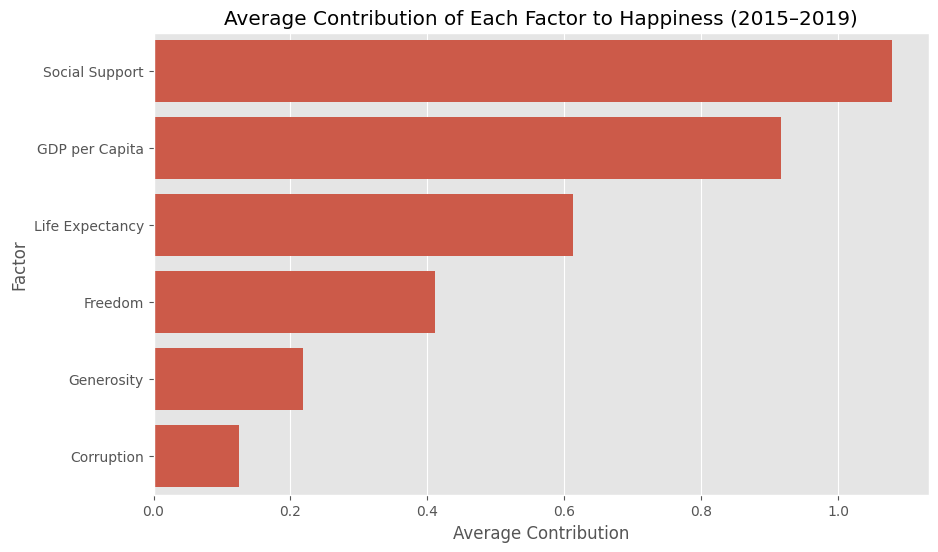

In [23]:
contribution_cols = ["GDP per Capita","Social Support","Life Expectancy","Freedom","Generosity","Corruption"]

mean_contribution = df_final[contribution_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=mean_contribution.values, y=mean_contribution.index)
plt.title("Average Contribution of Each Factor to Happiness (2015–2019)")
plt.xlabel("Average Contribution")
plt.ylabel("Factor")
plt.show()

**Interpretation:** On average, Social Support and GDP per Capita are the strongest contributors to the Happiness Score over the 2015–2019 period.
Life Expectancy, Freedom, Generosity, and Corruption contribute less overall, reinforcing the idea that economic and social support structures play an essential role in the national well-being.

To complement the analysis of average contributions, we examine how the contribution of each factor evolves over time between 2015 and 2019. This line plot allows us to assess whether the relative importance of different factors remains stable or exhibits meaningful changes across years.


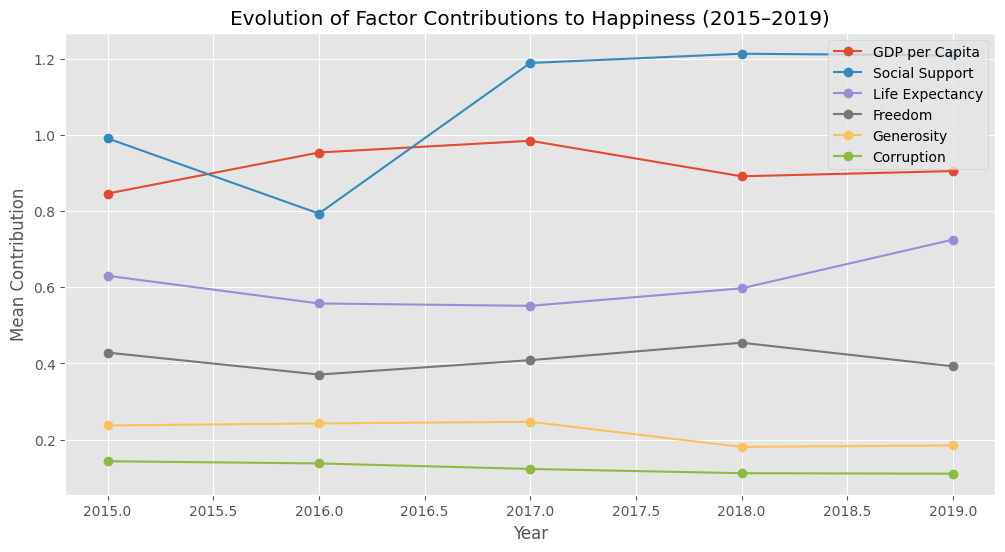

In [24]:

yearly = df_final.groupby("Year")[contribution_cols].mean()

plt.figure(figsize=(12,6))
for col in contribution_cols:
    plt.plot(yearly.index, yearly[col], marker='o', label=col)

plt.title("Evolution of Factor Contributions to Happiness (2015–2019)")
plt.xlabel("Year")
plt.ylabel("Mean Contribution")
plt.legend()
plt.grid(True)
plt.show()


**Interpretation:** The plot shows that the relative contributions of the main happiness factors remain broadly stable between 2015 and 2019, with no abrupt structural changes. Social Support and GDP per Capita consistently contribute the largest shares to the Happiness Score, although Social Support exhibits a noticeable increase after 2016. Life Expectancy shows a gradual upward trend toward the end of the period, while Freedom fluctuates modestly around a stable level. In contrast, Generosity and Corruption display low and relatively flat contributions, indicating a more limited role in explaining happiness differences over time.



## 5) Does the “strongest associated factor” change by year?

**Question:** For each year, which factor has the strongest absolute correlation with the Happiness Score?

While earlier sections examined overall correlations and average contributions, this step focuses on year-by-year dynamics. We identify, for each year, the factor that shows the strongest association with the Happiness Score, allowing us to assess whether the dominant relationship remains stable or changes over time.


In [25]:

year_strongest = {}

for year in df_final["Year"].unique():
    df_year = df_final[df_final["Year"] == year]
    corr = df_year[contribution_cols + ["Happiness Score"]].corr()["Happiness Score"].drop("Happiness Score")
    strongest = corr.abs().idxmax()
    year_strongest[year] = strongest

year_strongest

{np.int64(2015): 'GDP per Capita',
 np.int64(2016): 'GDP per Capita',
 np.int64(2017): 'GDP per Capita',
 np.int64(2018): 'GDP per Capita',
 np.int64(2019): 'GDP per Capita'}

**Interpretation:** The results show that GDP per Capita is the strongest associated factor with the Happiness Score in every year from 2015 to 2019. This consistency indicates a stable and robust relationship between income levels and happiness over the period studied. While other factors such as Social Support or Life Expectancy also exhibit positive correlations with happiness, none surpass GDP per Capita in terms of absolute correlation in any given year.

## 6) Which regions are the happiest on average?

**Question:** When averaging across 2015–2019, which regions have the highest mean Happiness Score?

To move from country-level patterns to broader geographic trends, we compare average happiness levels across regions. By aggregating Happiness Scores over the period 2015–2019, this analysis highlights which regions tend to exhibit higher overall well-being.


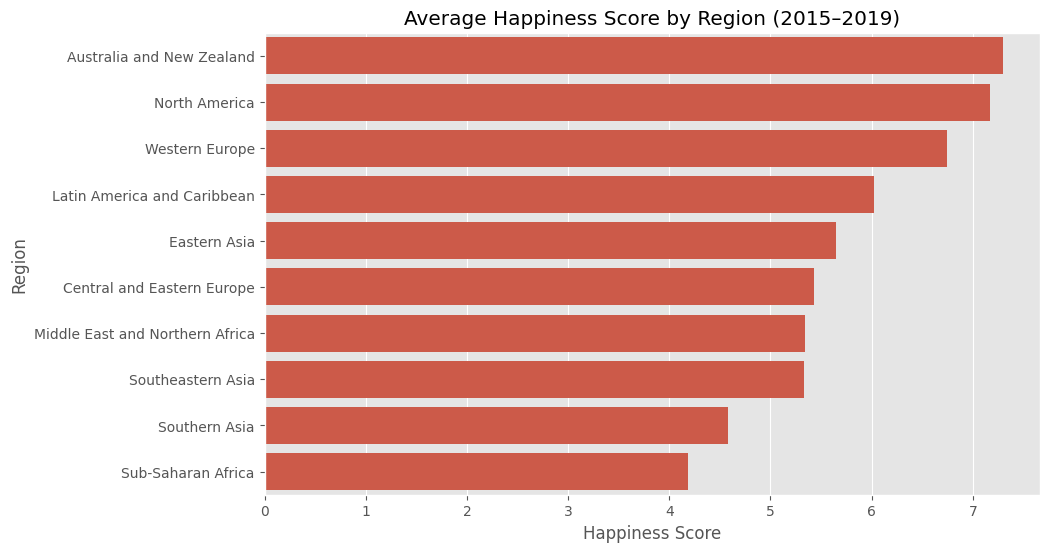

In [26]:
region_scores = df_final.groupby("Region")["Happiness Score"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=region_scores.values, y=region_scores.index)
plt.title("Average Happiness Score by Region (2015–2019)")
plt.xlabel("Happiness Score")
plt.show()

**Interpretation:** The bar chart highlights clear differences in average Happiness Scores across regions between 2015 and 2019. Australia and New Zealand, North America, and Western Europe rank among the happiest regions, with some average scores well above the global mean. By contrast, regions such as Sub-Saharan Africa and Southern Asia display some substantially lower average happiness levels. The significant gaps between regions indicate that regional context—likely reflecting differences in income levels, health outcomes, social support, and institutional quality—is strongly associated with overall happiness.

## Evolution of Happiness by Region (2015–2019)

**Question:** Do happiness levels evolve differently across regions between 2015 and 2019, or do regional gaps remain stable over time?

After comparing average happiness levels across regions, we now examine how these regional patterns evolve over time. This analysis tracks the average Happiness Score for each region between 2015 and 2019, allowing us to assess whether regional differences remain stable or whether some regions experience faster improvements than others.

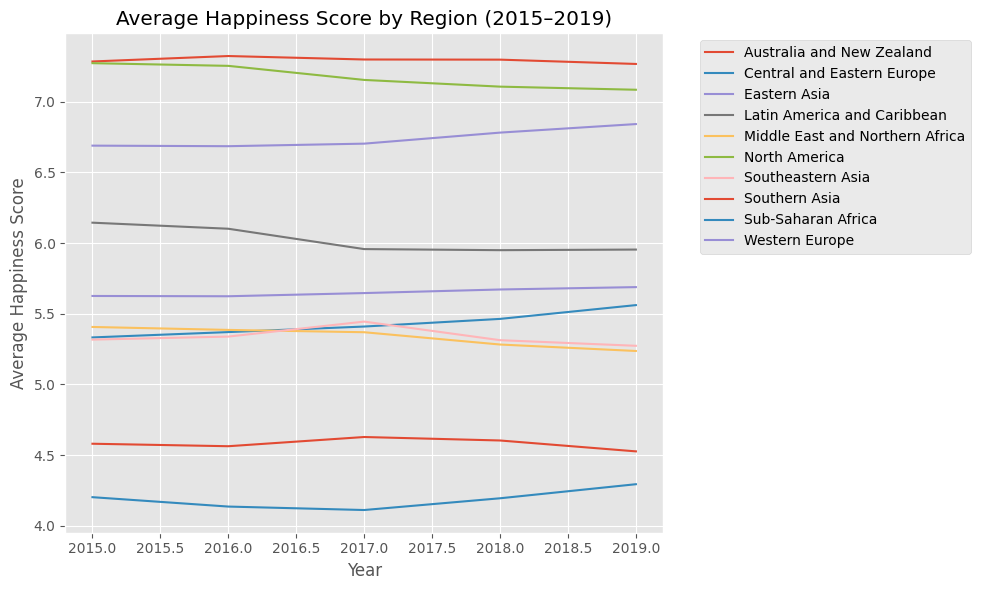

In [27]:
region_year_avg = (
    df_final
    .groupby(["Year", "Region"])["Happiness Score"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))
for region in region_year_avg["Region"].unique():
    subset = region_year_avg[region_year_avg["Region"] == region]
    plt.plot(subset["Year"], subset["Happiness Score"], label=region)

plt.xlabel("Year")
plt.ylabel("Average Happiness Score")
plt.title("Average Happiness Score by Region (2015–2019)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Interpretation:** The regional trends show that differences in happiness across regions remain largely persistent between 2015 and 2019. Regions such as Australia and New Zealand, North America, and Western Europe consistently maintain the highest average happiness levels, while Sub-Saharan Africa and Southern Asia remain at the lower end throughout the period. Most regional lines evolve in a broadly parallel manner, indicating that relative regional rankings change little over time. Although some regions—such as Eastern Asia and Western Europe—exhibit modest upward trends, these changes are not large enough to substantially reduce the gaps between regions.

## 7) How do factor profiles differ across regions?

**Question:** Which factors (GDP, social support, etc.) are systematically higher or lower depending on the region?

Beyond differences in overall happiness levels, regions may also differ in the underlying factors that contribute to happiness. This analysis compares the average contribution of key factors across regions, allowing us to identify systematic regional patterns in economic, social, and institutional dimensions.

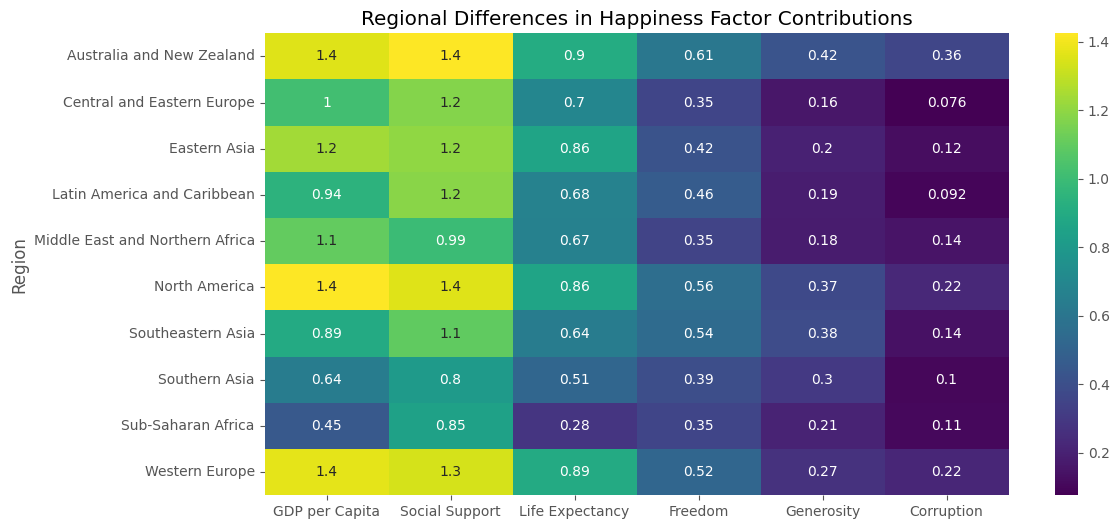

In [28]:
region_factors = df_final.groupby("Region")[contribution_cols].mean()

plt.figure(figsize=(12,6))
sns.heatmap(region_factors, annot=True, cmap="viridis")
plt.title("Regional Differences in Happiness Factor Contributions")
plt.show()

**Interpretation:** The heatmap reveals clear regional differences in the relative contributions of happiness factors. Regions with the highest happiness levels such as North America, Western Europe, and Australia and New Zealand, exhibit strong contributions from both GDP per Capita and Social Support, alongside high Life Expectancy. By contrast, regions with lower happiness outcomes, such as Sub-Saharan Africa and Southern Asia, display substantially weaker economic and health-related contributions. Freedom shows small variation across regions, while Generosity and Corruption remain comparatively low everywhere, indicating that the economic and social foundations play a more central role than institutional or altruistic factors in explaining the regional happiness differences.



## 8) Which countries rank highest and lowest (on average) in 2015–2019?

**Question:** Which countries consistently appear at the top and bottom when averaging Happiness Score across the five years?

In [29]:

mean_happiness = df_final.groupby("Country")["Happiness Score"].mean().sort_values(ascending=False)

top10 = mean_happiness.head(10)
bottom10 = mean_happiness.tail(10)

print("The top 10 happiest countries (2015–2019):")
display(top10)

print("The bottom 10 least happy countries (2015–2019):")
display(bottom10)

The top 10 happiest countries (2015–2019):


Country
Denmark       7.546
Norway        7.541
Finland       7.538
Switzerland   7.511
Iceland       7.511
Netherlands   7.405
Canada        7.351
Sweden        7.319
New Zealand   7.313
Australia     7.276
Name: Happiness Score, dtype: float64

The bottom 10 least happy countries (2015–2019):


Country
Madagascar                 3.745
Yemen                      3.626
Togo                       3.544
Afghanistan                3.513
Tanzania                   3.466
Rwanda                     3.439
South Sudan                3.383
Syria                      3.292
Central African Republic   3.134
Burundi                    3.079
Name: Happiness Score, dtype: float64

**Interpretation:** The ranking highlights countries that are persistently on the top or bottom of the happiness distribution when averaging over 2015–2019. Countries like Switzerland, Iceland, and the Netherlands consistently appear among the happiest, suggesting a stable mix of high income, strong social support, and effective institutions. In contrast, countries like Burundi, the Central African Republic, and Syria rank among the least happy, reflecting structural challenges rather than short-term fluctuations.

The following graphs represent the 10 happiest and least happiest countries. The y-axis is adapted to highlight the differences between them.

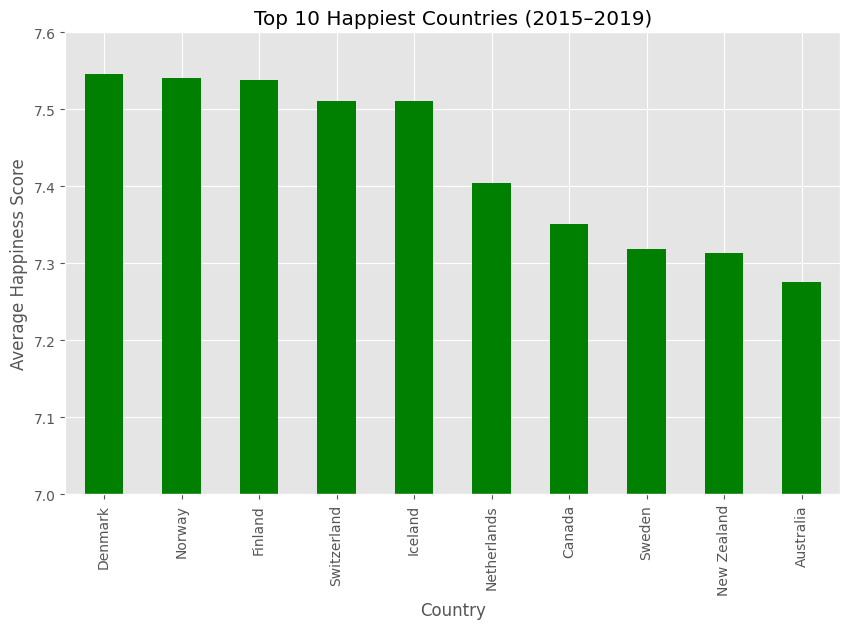

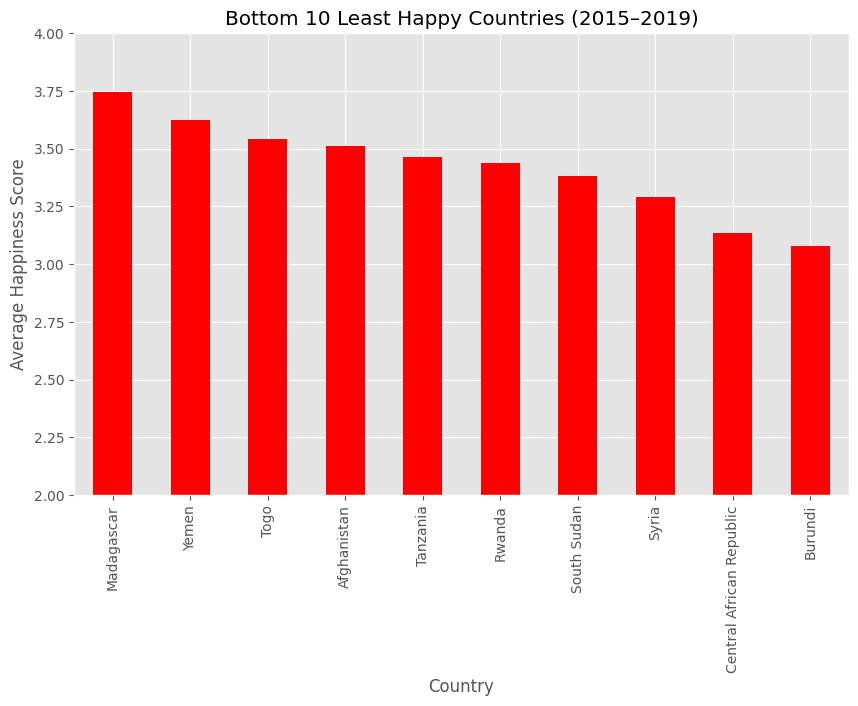

In [30]:
plt.figure(figsize=(10,6))
top10.plot(kind="bar", color="green")
plt.ylabel("Average Happiness Score")
plt.ylim(7.0, 7.6)
plt.title("Top 10 Happiest Countries (2015–2019)")
plt.show()

plt.figure(figsize=(10,6))
bottom10.plot(kind="bar", color="red")
plt.title("Bottom 10 Least Happy Countries (2015–2019)")
plt.ylabel("Average Happiness Score")
plt.ylim(2, 4)
plt.show()

**Interpretation:** The bar charts illustrate a clear and persistent gap between the happiest and least happy countries when averaging over 2015–2019. The top-ranked countries such as Denmark, Norway, Finland, Switzerland, and Iceland exhibit very high and closely clustered happiness scores, indicating consistently strong well-being outcomes. In contrast, the bottom-ranked countries, including Burundi, the Central African Republic, and Syria, display lower scores, with a much wider separation from the global top. This contrast bolsters earlier findings that sustained differences in income levels, social support and institutional quality are highly associated with long-term happiness disparities across countries.

## 9) Top vs bottom countries: what explains the gap?

**Question:** Which factors differ the most between the top 15 and bottom 15 happiest countries (average over 2015–2019)?

To better understand the drivers of large cross-country happiness differences, we directly compare the happiest and least happy countries. By contrasting the average factor contributions of the top 15 and bottom 15 countries over 2015–2019, this analysis highlights which dimensions most strongly differentiate high- and low-happiness outcomes.


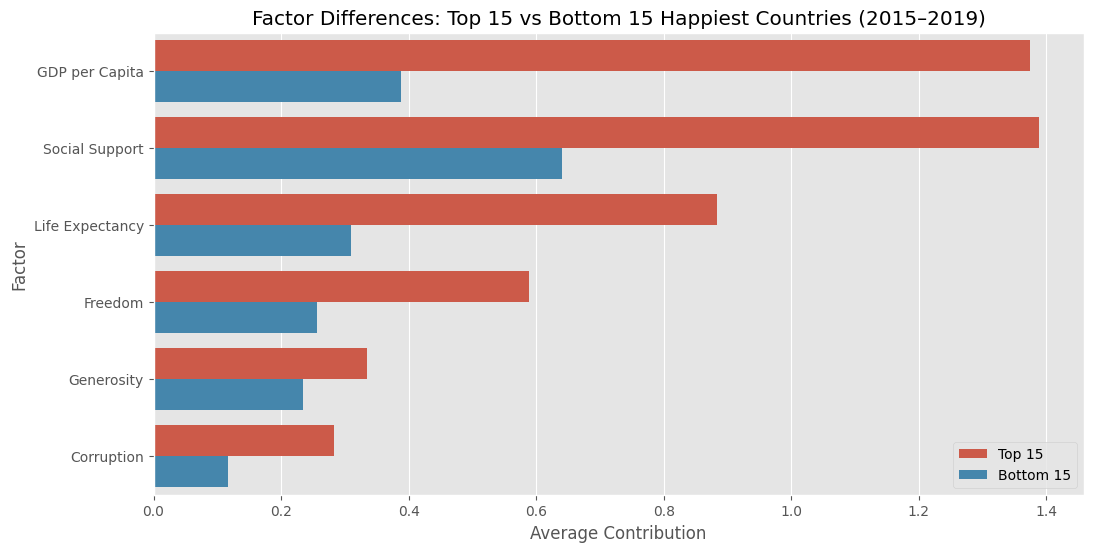

In [31]:
top = df_final.groupby("Country")["Happiness Score"].mean().sort_values(ascending=False).head(15).index
bottom = df_final.groupby("Country")["Happiness Score"].mean().sort_values().head(15).index

top_df = df_final[df_final["Country"].isin(top)]
bottom_df = df_final[df_final["Country"].isin(bottom)]

comparison = pd.DataFrame({
    "Top 15": top_df[contribution_cols].mean(),
    "Bottom 15": bottom_df[contribution_cols].mean()
}).reset_index().rename(columns={"index": "Factor"})

comparison_long = comparison.melt(
    id_vars="Factor",
    var_name="Group",
    value_name="Average Contribution")

plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_long, x="Average Contribution", y="Factor", hue="Group")
plt.title("Factor Differences: Top 15 vs Bottom 15 Happiest Countries (2015–2019)")
plt.ylabel("Factor")
plt.xlabel("Average Contribution")
plt.legend(title="")
plt.show()

**Interpretation**: The comparison shows that the largest gaps between the top 15 and bottom 15 happiest countries are driven by GDP per Capita and Social Support, which display substantially higher average contributions among the happiest countries. Life Expectancy and Freedom also contribute to the gap, but to a lesser extent. In contrast, differences in Generosity and Corruption are relatively small, indicating that these factors play a more limited role in separating the happiest and least happy countries. Overall, the results reinforce the central importance of economic resources, social support, and health in explaining cross-country happiness disparities.

**Clarifying note: correlation vs contribution:** It may seem surprising that social support appears as the largest average contributor to the Happiness Score while GDP shows a stronger correlation with happiness. This difference comes from the distinction between correlation and contribution.

Correlation measures how strongly two variables move together. GDP is highly correlated with happiness because wealthier countries tend to have better living conditions and services.

However, the contribution values come from the official regression model of the World Happiness Report. In this model, social support receives the largest coefficient and thus explains the biggest share of the Happiness Score. This reflects the chief role of social relationships in subjective well-being, independently of income levels.

One more thing worth flagging: the six factor columns are not independent, external measurements, they are the report's own regression-derived contribution terms, and the Happiness Score is built (largely) by adding them together with a residual. So part of why GDP per Capita “wins” every correlation check in the section above is close to true by construction, since it is a summand of the very total we are correlating it against. We still think the relative comparison across countries and years is informative, but we would not want to oversell it as an independent, causal finding.


 # Conclusion 
 <a id="conclusion"></a>

The aim of this project was to study the factors leading to happiness and to explore the evolution of these relationships between 2015 and 2019. Thanks to the yearly datasets from the World Happiness Report, we analysed the data in order to produce a clear study of these interactions.

Our analysis focused on contribution indicators (which describe how much each factor contributes to the overall Happiness Score). We standardised names across years to make sure that all datasets could be combined despite the differences in the terminology.

The results show that GDP per Capita, social support, life expectancy, and freedom are the variables most associated with the Happiness Score. These indicators have the strongest positive correlations with happiness across all years. We also note that other factors such as generosity and perceptions of corruption still play a substantial part.

Trend analysis indicates that the averages of these indicators remain relatively stable between 2015 and 2019. The period we studied does not include major global shocks and the variations are gradual. However, the ranking analysis shows consistent differences between countries. Northern European countries rank among the happiest, while countries with conflict, economic instability or  corruption tend to rank lower. We can deduce that characteristics such as economic prosperity, health and social cohesion play a central role in shaping well-being.

Some limits should however be acknowledged. Some years contained missing values. Moreover, the Happiness Score is based on survey data, which may introduce measurement biases. Finally, correlation-based analysis does not establish a certain causality.


<a id="sources"></a>
# Sources.  <sup><a href="#source-17">17</a></sup>, <sup><a href="#source-18">18</a></sup>



<a id="source-1"></a>
**1. Seaborn Developers.** *Seaborn Tutorial.*  
Introduction to Seaborn and its main visualization features.  
https://seaborn.pydata.org/

---

<a id="source-2"></a>
**2. Seaborn Developers.** *Seaborn API Reference.*  
Reference documentation for Seaborn functions and parameters.  
https://seaborn.pydata.org/api.html

---

<a id="source-3"></a>
**3. Matplotlib Documentation.** *ggplot Style Sheet.*  
Explanation of the ggplot-style theme in Matplotlib.  
https://matplotlib.org/stable/gallery/style_sheets/ggplot.html

---

<a id="source-4"></a>
**4. Pandas Documentation.** *Display Options.*  
Overview of Pandas options for controlling DataFrame display.  
https://pandas.pydata.org/pandas-docs/stable/user_guide/options.html

---

<a id="source-5"></a>
**5. Stack Overflow Contributors.** *Import multiple CSV files into pandas and concatenate into one DataFrame.*  
Examples showing how to load multiple CSV files and combine them using pandas.  
https://stackoverflow.com/questions/20906474/import-multiple-csv-files-into-pandas-and-concatenate-into-one-dataframe

---

<a id="source-6"></a>
**6. GeeksforGeeks.** *How to Merge multiple CSV Files into a single Pandas dataframe.*  
Tutorial demonstrating how to merge several CSV files into one Pandas DataFrame.  
https://www.geeksforgeeks.org/python/how-to-merge-multiple-csv-files-into-a-single-pandas-dataframe/

---

<a id="source-7"></a>
**7. GeeksforGeeks.** *Working with Missing Data in Pandas.*  
Guide to detecting and handling missing values in Pandas.  
https://www.geeksforgeeks.org/data-analysis/working-with-missing-data-in-pandas/

---

<a id="source-8"></a>
**8. Pandas Documentation.** *DataFrame Column Management (`rename`).*  
How to rename and manage DataFrame columns in Pandas.  
https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.rename.html

---

<a id="source-9"></a>
**9. Pandas Documentation.** *Concatenating DataFrames (`pandas.concat`).*  
Reference for combining multiple DataFrames into one.  
https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.concat.html

---

<a id="source-10"></a>
**10. Pandas Documentation.** *Detecting Missing Data (`DataFrame.isna`).*  
Explanation of how to identify missing values in Pandas.  
https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.isna.html

---

<a id="source-11"></a>
**11. Tutorial Reference.** *Creating a Dictionary from DataFrame Columns in Pandas.*  
Shows how to convert DataFrame columns into a dictionary.  
https://tutorialreference.com/python/examples/faq/python-pandas-how-to-create-dictionary-from-two-columns-of-dataframe

---

<a id="source-12"></a>
**12. DNMTechs.** *Conditionally Filling Column Values in Pandas.*  
Examples of updating DataFrame values based on conditions.  
https://dnmtechs.com/conditionally-filling-column-values-in-pandas-based-on-another-column/

---

<a id="source-13"></a>
**13. Pandas Documentation.** *Descriptive Statistics (`DataFrame.describe`).*  
Reference for generating summary statistics in Pandas.  
https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.describe.html

---

<a id="source-14"></a>
**14. Data to Fish.** *How to Create a Correlation Matrix Using Pandas.*  
Tutorial on computing correlation matrices with Pandas.  
https://www.datatofish.com/correlation-matrix-pandas/

---

<a id="source-15"></a>
**15. DataCamp.** *Matplotlib Time Series Line Plot.*  
Examples of plotting time series data with Matplotlib.  
https://www.datacamp.com/tutorial/matplotlib-time-series-line-plot

---

<a id="source-16"></a>
**16. GeeksforGeeks.** *How to Plot a Time Series in Matplotlib.*  
Step-by-step guide to plotting time series data.  
https://www.geeksforgeeks.org/python/how-to-plot-a-time-series-in-matplotlib/

---

<a id="source-17"></a>
**17. OpenAI — ChatGPT.** *Structuring and Formatting a Sources Section in Jupyter Notebooks.*  
Help on structuring and formatting / markdown sources. Help with consistency.  
https://chat.openai.com/

---

<a id="source-18"></a>
**18. Sebastian Raschka.** *Creating a Table of Contents with Internal Links in IPython Notebooks.*  
Guide to adding internal navigation links in notebooks.  
https://sebastianraschka.com/Articles/2014_ipython_internal_links.html
